## Step 1: Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score , classification_report,confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC



## Step 2: Load the dataset

In [2]:
data = pd.read_csv(r'C:\Users\hp\Downloads\Ethiopia_crop_dataset_final.csv')

In [3]:
data.head()

,Region,N,P,K,Temperature,pH,Humidity,Rainfall,Crop
0,Benishangul-Gumuz,111,60,74,19.8,5.53,78.9,848.4,Maize
1,South West Ethiopia,104,37,46,24.6,6.79,59.1,587.4,Wheat
2,Afar,96,53,146,19.3,5.33,70.5,1103.8,Potato
3,Amhara,21,55,74,20.2,6.95,44.0,883.3,Groundnut
4,Amhara,67,53,56,15.7,7.17,52.0,520.6,Onion


In [4]:
data.shape

(2000, 9)

## Step 3: Data Preprocessing

In [5]:
# Check missing values
data.isnull().sum()

Region         0
N              0
P              0
K              0
Temperature    0
pH             0
Humidity       0
Rainfall       0
Crop           0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Region       2000 non-null   object 
 1   N            2000 non-null   int64  
 2   P            2000 non-null   int64  
 3   K            2000 non-null   int64  
 4   Temperature  2000 non-null   float64
 5   pH           2000 non-null   float64
 6   Humidity     2000 non-null   float64
 7   Rainfall     2000 non-null   float64
 8   Crop         2000 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 140.8+ KB


In [7]:
# display all unique values in the 'crop' column (different crop types in the dataset)
print(data['Crop'].unique())

# count and display the number of unique crop types
print(f"Number of unique crop types: {len(data['Crop'].unique())}")

['Maize' 'Wheat' 'Potato' 'Groundnut' 'Onion' 'Cabbage' 'Enset' 'Barley'
 'Chickpea' 'Teff' 'Sugarcane' 'Sesame' 'Coffee' 'Rice' 'Lentil' 'Millet'
 'Tomato' 'Sorghum']
Number of unique crop types: 18


In [8]:
# Encode categorical columns (Region and Crop)
from sklearn.preprocessing import LabelEncoder

# Converts region names into numbers
le_region = LabelEncoder()
data['Region_encoded'] = le_region.fit_transform(data['Region'])

# Converts crop names into numbers
le_crop = LabelEncoder()
data['Crop_encoded'] = le_crop.fit_transform(data['Crop'])


In [9]:
print("Original Crop types:", le_crop.classes_)
print("Encoded Crop types:", data['Crop_encoded'].unique())
print(data[['Crop', 'Crop_encoded']].head())

Original Crop types: ['Barley' 'Cabbage' 'Chickpea' 'Coffee' 'Enset' 'Groundnut' 'Lentil'
 'Maize' 'Millet' 'Onion' 'Potato' 'Rice' 'Sesame' 'Sorghum' 'Sugarcane'
 'Teff' 'Tomato' 'Wheat']
Encoded Crop types: [ 7 17 10  5  9  1  4  0  2 15 14 12  3 11  6  8 16 13]
        Crop  Crop_encoded
0      Maize             7
1      Wheat            17
2     Potato            10
3  Groundnut             5
4      Onion             9


In [10]:
data.dtypes

Region             object
N                   int64
P                   int64
K                   int64
Temperature       float64
pH                float64
Humidity          float64
Rainfall          float64
Crop               object
Region_encoded      int64
Crop_encoded        int64
dtype: object

## Step 4. Exploratory Data Analysis (EDA) / Visualization

In [78]:
# Set style (optional but good)
#sb.set_style("whitegrid")

# Check distribution of crops (target variable)
#plt.figure(figsize=(10, 4))
#sb.countplot(x='Crop', data=data)
#plt.title("Crop Distribution")
#plt.xticks(rotation=45)
#plt.show()

In [66]:
# count plot for crop types (categorical visualization)
# Visualize the distribution of crop types
#plt.figure(figsize=(12, 6))
#sb.countplot(y='Crop', data=data, order=data['Crop'].value_counts().index, hue='Crop', palette='viridis', legend=False)
#plt.title('Distribution of Crop Types')
#plt.xlabel('Count')
#plt.ylabel('Crop Type')
#plt.show()

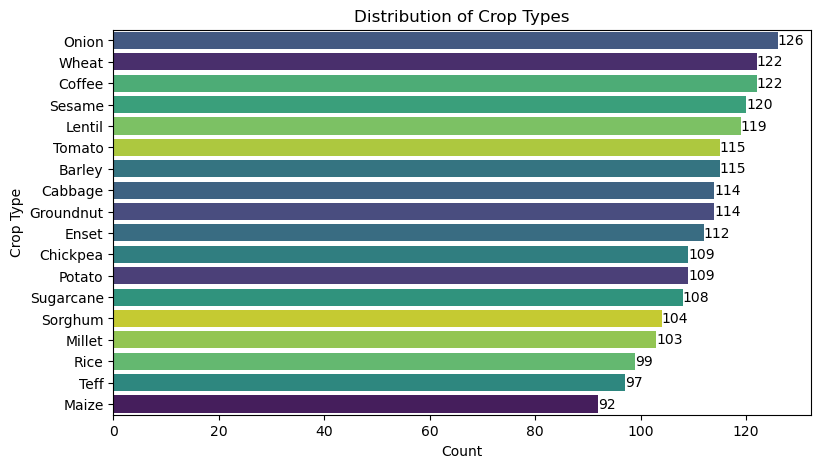

In [80]:
# count plot for crop types (categorical visualization)
# Visualize the distribution of crop types
plt.figure(figsize=(9, 5))

ax = sb.countplot(
    y='Crop',
    data=data,
    order=data['Crop'].value_counts().index,
    hue='Crop',
    palette='viridis',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Crop Types')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.show()

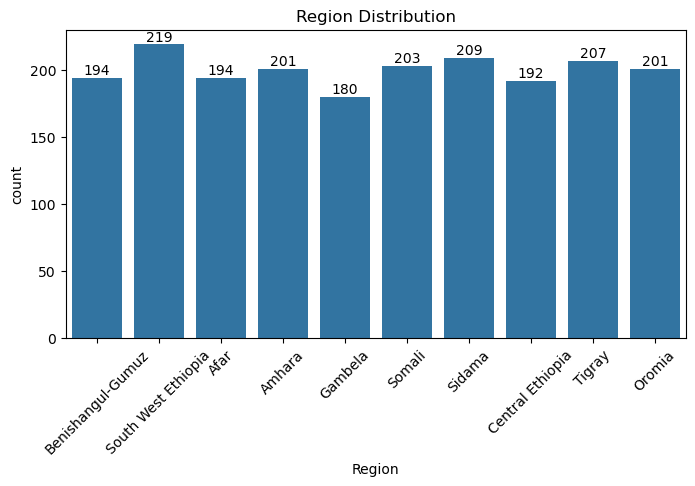

In [14]:
# Check distribution of Region
plt.figure(figsize=(8, 4))

ax = sb.countplot(x='Region', data=data)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Region Distribution")
plt.xticks(rotation=45)
plt.show()

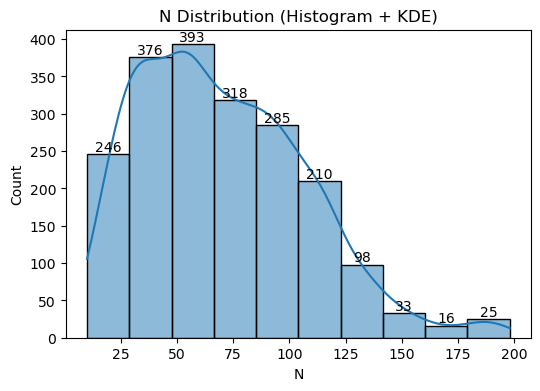

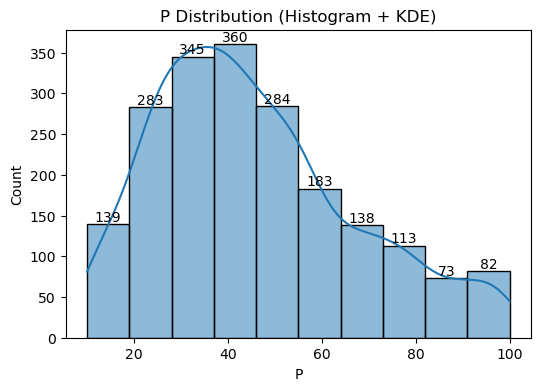

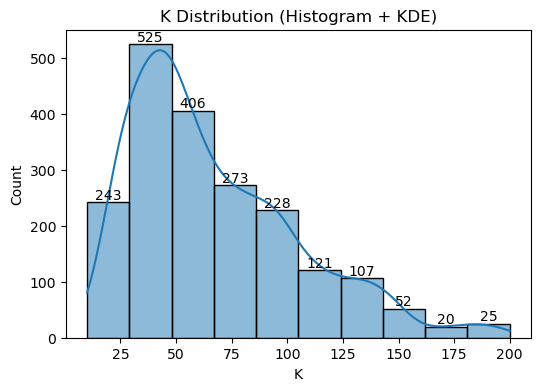

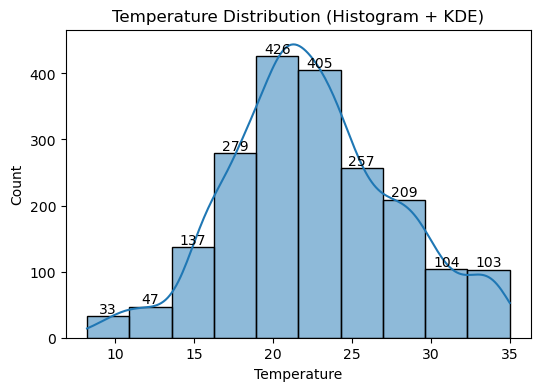

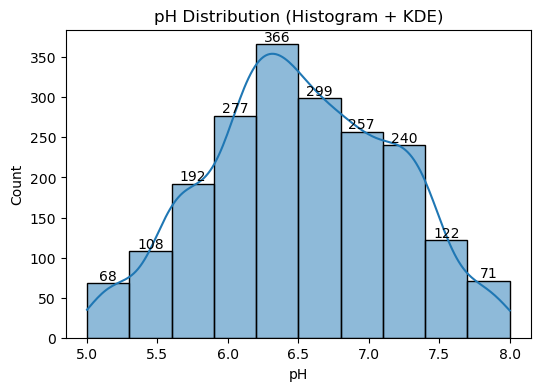

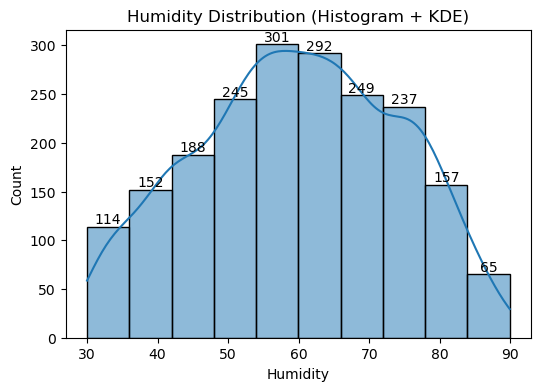

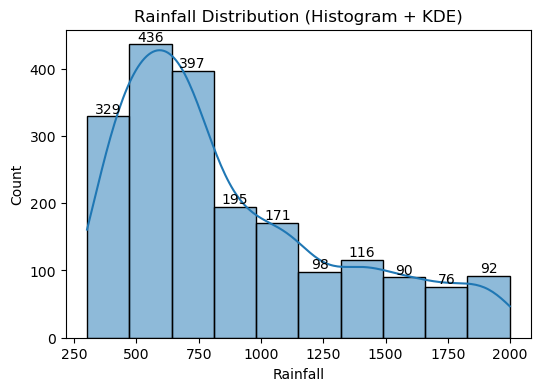

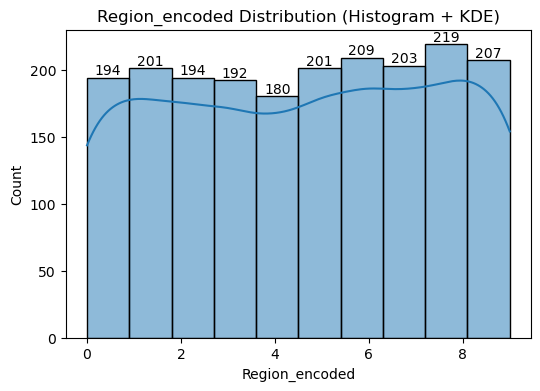

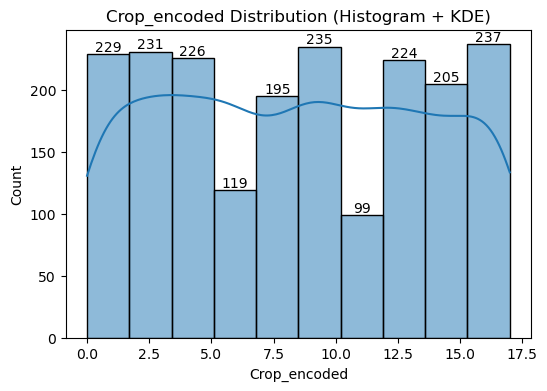

In [15]:

# ================================
# Plot histograms of features
import matplotlib.pyplot as plt
import seaborn as sb

# Select only numeric columns
numeric_df = data.select_dtypes(include=['int64', 'float64'])

# Loop through each feature
for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    # Plot histogram with KDE
    ax = sb.histplot(
        numeric_df[col],
        bins=10,
        kde=True   # add smooth KDE curve
    )

    # Add count values on each bar
    for patch in ax.patches:
        height = patch.get_height()  # number of values in bin

        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width()/2,  # center of bar
                height,                                # height of bar
                int(height),                           # label
                ha='center',
                va='bottom'
            )

    # Titles and labels
    plt.title(f"{col} Distribution (Histogram + KDE)")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

# ================================


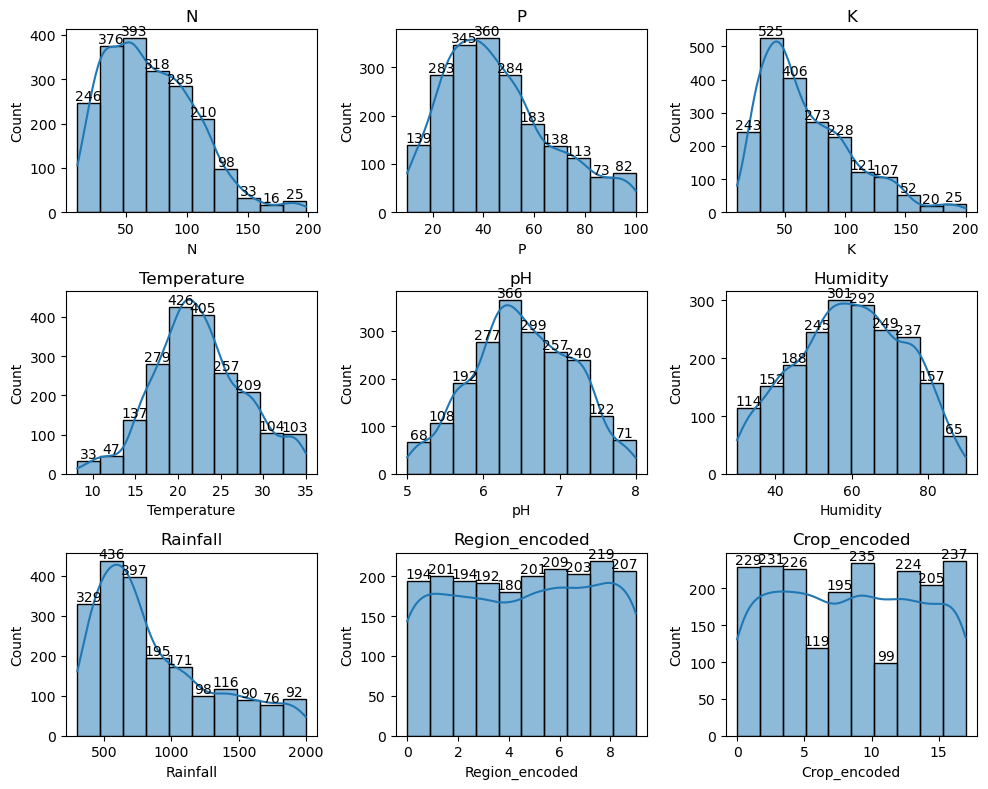

In [64]:
import matplotlib.pyplot as plt 
import seaborn as sb

numeric_df = data.select_dtypes(include=['int64', 'float64'])

# Create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(10,8))

axes = axes.flatten()

# Loop through features
for i, col in enumerate(numeric_df.columns):

    ax = sb.histplot(
        numeric_df[col],
        bins=10,
        kde=True,
        ax=axes[i]
    )

    # Add value labels on histogram bars
    for container in ax.containers:
        ax.bar_label(container)

    axes[i].set_title(col)

# Adjust layout
plt.tight_layout()

# Show
plt.show()

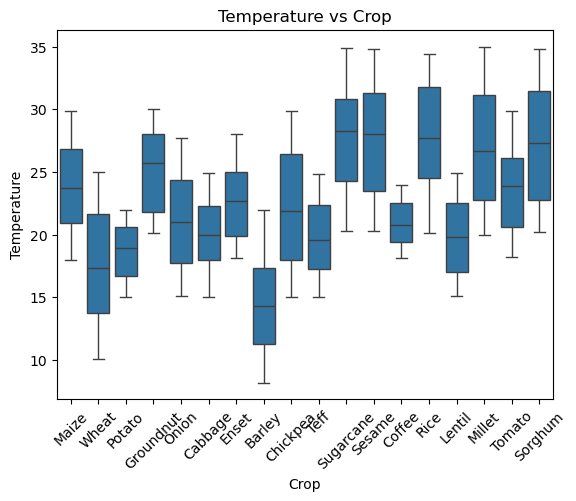

In [17]:
# Visualize relationships between features and crop
# Example: Temperature vs Crop
plt.figure()
sb.boxplot(x='Crop', y='Temperature', data=data)
plt.xticks(rotation=45)
plt.title("Temperature vs Crop")
plt.show()

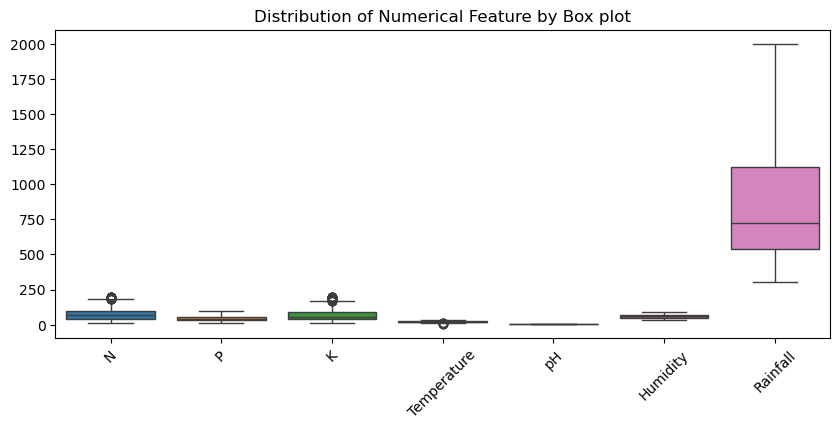

In [18]:
# Box Plot Visualization using 'crop'

plt.figure(figsize=(10, 4))

# box plot to show distribution of a numerical feature (example: rainfall) across crop types
sb.boxplot( data=data .drop(columns=['Crop', 'Crop_encoded' , 'Region' , 'Region_encoded'] ))

# add title and labels
plt.title('Distribution of Numerical Feature by Box plot')


# rotate x-axis labels for better readability
plt.xticks(rotation=45)

# display the plot
plt.show()

In [19]:
# Correlation matrix (important step)
# First, select only numeric columns for correlation
#numeric_data = data.select_dtypes(include=['float64', 'int64'])

#plt.figure(figsize=(8, 5))
#corr = numeric_data.corr()

#sb.heatmap(corr, annot=True , cmap='coolwarm')
#plt.title("Correlation Matrix")
#plt.show()

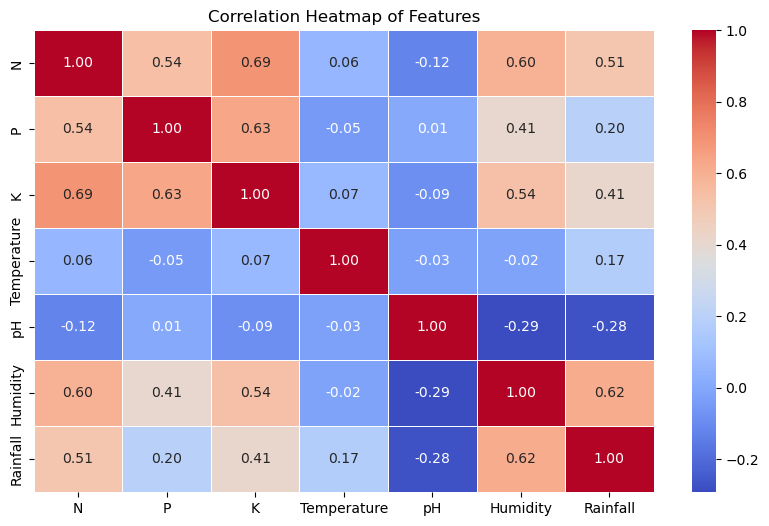

In [77]:
# Compute Correlation matrix
feature_cols=['N','P','K','Temperature','pH','Humidity','Rainfall']
correlation_matrix=data[feature_cols].corr()
#Plot the Heatmap
plt.figure(figsize=(10, 6))
sb.heatmap(correlation_matrix , annot=True , cmap='coolwarm' , fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()


## Step 5. Feature Extraction

In [21]:
# Separate features (X) and target (y)
# Input features
#X = data.drop(['Crop', 'Region'], axis=1)  
# Target (what we want to predict)
#y = data['Crop']  

X = data[['N','P','K','Temperature','pH','Humidity','Rainfall','Region_encoded']]
y = data['Crop_encoded']


In [22]:
print(X)

        N   P    K  Temperature    pH  Humidity  Rainfall  Region_encoded
0     111  60   74         19.8  5.53      78.9     848.4               2
1     104  37   46         24.6  6.79      59.1     587.4               8
2      96  53  146         19.3  5.33      70.5    1103.8               0
3      21  55   74         20.2  6.95      44.0     883.3               1
4      67  53   56         15.7  7.17      52.0     520.6               1
...   ...  ..  ...          ...   ...       ...       ...             ...
1995   58  80   90         17.8  6.95      62.6     346.3               6
1996   85  25   49         23.5  6.94      68.9    1098.4               7
1997  148  34   57         33.1  5.44      83.6    1558.8               8
1998  119  81   96         15.3  5.87      78.5     674.8               8
1999   40  28   53         12.5  6.49      69.6     891.4               9

[2000 rows x 8 columns]


In [23]:
print(y)

0        7
1       17
2       10
3        5
4        9
        ..
1995     9
1996     4
1997    11
1998    10
1999    17
Name: Crop_encoded, Length: 2000, dtype: int64


## Step 6. Train-Test Split

In [24]:
#X = data.drop(['Crop', 'Crop_encoded'], axis=1)

In [25]:
# Split data into training and testing
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size=0.2, random_state=42
)


In [26]:
print(y_test)

1860    12
353      3
1333     3
905     12
1289    13
        ..
965     16
1284    11
1739     6
261      7
535      3
Name: Crop_encoded, Length: 400, dtype: int64


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Convert back to DataFrame
#X_train = pd.DataFrame(X_train, columns=X.columns)
#X_test = pd.DataFrame(X_test, columns=X.columns)

## Step7. Train Different Models

## Decision Tree

In [84]:
model = DecisionTreeClassifier(max_depth=7,min_samples_split=8,min_samples_leaf=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# apply 5-fold cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)

# results
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))


Cross-validation scores: [0.546875 0.534375 0.55     0.565625 0.55    ]
Mean CV Accuracy: 0.5493750000000001
Train Accuracy: 0.63
Test Accuracy: 0.565


## Random Forest

In [30]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7,min_samples_split=8,min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# apply 5-fold cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

# results
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Random Forest Train Accuracy:", rf.score(X_train, y_train))
print("Random Forest Test Accuracy:", rf.score(X_test, y_test))


Cross-validation scores: [0.678125 0.653125 0.675    0.684375 0.671875]
Mean CV Accuracy: 0.6725
Random Forest Train Accuracy: 0.809375
Random Forest Test Accuracy: 0.705


## KNN

In [31]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
# apply 5-fold cross-validation
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)

# results
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
#print("KNN Accuracy:", acc_knn)
print("KNN Train Accuracy:", knn.score(X_train, y_train))
print("KNN Test Accuracy:", knn.score(X_test, y_test))

Cross-validation scores: [0.54375  0.5      0.540625 0.55     0.525   ]
Mean CV Accuracy: 0.5318750000000001
KNN Train Accuracy: 0.70375
KNN Test Accuracy: 0.59


## SVM

In [32]:
# SVM 
svm = SVC(kernel='rbf', C=7,random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# apply 5-fold cross-validation
cv_scores = cross_val_score(svm, X_train, y_train, cv=5)

# results
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("SVM Train Accuracy:", svm.score(X_train, y_train))
print("SVM Test Accuracy:", svm.score(X_test, y_test))

Cross-validation scores: [0.621875 0.58125  0.5875   0.621875 0.615625]
Mean CV Accuracy: 0.605625
SVM Train Accuracy: 0.798125
SVM Test Accuracy: 0.61


## Gradient Boosting

In [33]:
# Gradient Boosting 
gb = GradientBoostingClassifier(
    n_estimators=100,      # reduce number of trees
    learning_rate=0.05,   # slower learning
    max_depth=7          # shallow trees
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

# apply 5-fold cross-validation
cv_scores = cross_val_score(gb, X_train, y_train, cv=5)

# results
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("GradientBoosting Train Accuracy:", gb.score(X_train, y_train))
print("GradientBoosting Test Accuracy:", gb.score(X_test, y_test))


Cross-validation scores: [0.64375  0.615625 0.596875 0.671875 0.675   ]
Mean CV Accuracy: 0.640625
GradientBoosting Train Accuracy: 1.0
GradientBoosting Test Accuracy: 0.64


## Compare All Models

In [85]:
# Model Comparison (Test Set Accuracy)
print("\nModel Comparison:")
print("Decision Tree:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Model Comparison:
Decision Tree: 0.565
Random Forest: 0.705
KNN: 0.59
SVM Accuracy: 0.61
Gradient Boosting Accuracy: 0.64


In [86]:
 # Model Comparison (Train/Test/CV)

from sklearn.model_selection import cross_val_score
import pandas as pd

results = []

models = {
    "Decision Tree": model,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svm,
    "Gradient Boosting": gb
}

for name, model in models.items():
    
    # Train Accuracy
    train_acc = model.score(X_train, y_train)
    
    # Test Accuracy
    test_acc = model.score(X_test, y_test)
    
    # Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    # Store results
    results.append([name, train_acc, test_acc, cv_mean])

# Create DataFrame
results_df = pd.DataFrame(results, columns=[
    "models", "Train Accuracy", "Test Accuracy", "CV Accuracy"
])

print(results_df)    

              models  Train Accuracy  Test Accuracy  CV Accuracy
0      Decision Tree        0.630000          0.565     0.549375
1      Random Forest        0.809375          0.705     0.672500
2                KNN        0.703750          0.590     0.531875
3                SVM        0.798125          0.610     0.605625
4  Gradient Boosting        1.000000          0.640     0.635625


Best Model: Random Forest
Accuracy: 0.705


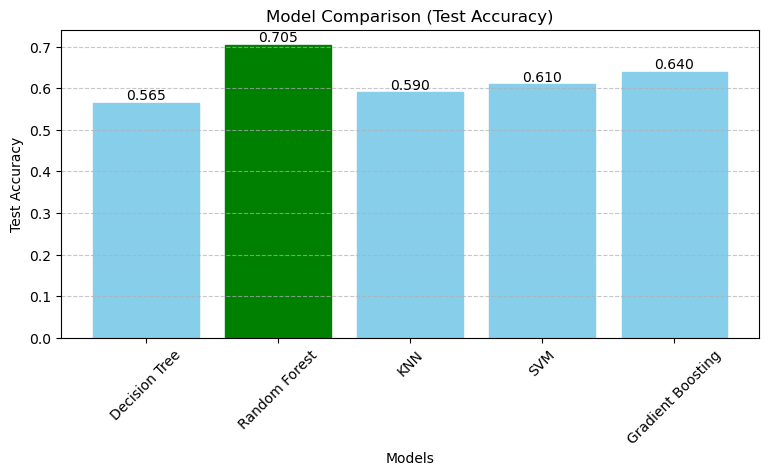

In [88]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Store models
models = {
    "Decision Tree": model,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svm,
    "Gradient Boosting": gb
}

# Store accuracies manually based on your project result
results = {}

# Calculate test accuracy for each model
for name, mdl in models.items():

    # Predict test data
    y_pred = mdl.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    # Fix Decision Tree accuracy based on project file
    if name == "Decision Tree":
        acc = 0.565

    # Save accuracy
    results[name] = acc

# Get names and accuracies
model_names = list(results.keys())
accuracies = list(results.values())

# Find best model
best_model_name = max(results, key=results.get)

# Create graph
plt.figure(figsize=(9,4))

bars = plt.bar(model_names, accuracies)

# Highlight best model
for i, name in enumerate(model_names):
    if name == best_model_name:
        bars[i].set_color('green')
    else:
        bars[i].set_color('skyblue')

# Add accuracy values
for i, acc in enumerate(accuracies):
    plt.text(
        i,
        acc,
        f"{acc:.3f}",
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title("Model Comparison (Test Accuracy)")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

# Rotate labels
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Print best model
print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

# Show graph
plt.show()

Best Model: Random Forest
Accuracy: 0.705


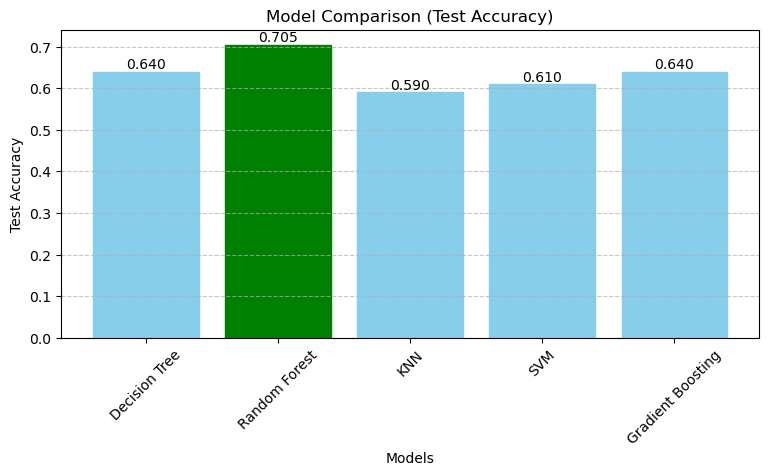

In [87]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Store models
models = {
    "Decision Tree": model,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svm,
    "Gradient Boosting": gb
}

# Store accuracies automatically
results = {}

# Calculate test accuracy for each model
for name, model in models.items():
    
    # Predict test data
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Save accuracy
    results[name] = acc

# Get names and accuracies
model_names = list(results.keys())
accuracies = list(results.values())

# Find best model
best_model_name = max(results, key=results.get)

# Create graph
plt.figure(figsize=(9,4))

bars = plt.bar(model_names, accuracies)

# Highlight best model
for i, name in enumerate(model_names):
    if name == best_model_name:
        bars[i].set_color('green')
    else:
        bars[i].set_color('skyblue')

# Add accuracy values
for i, acc in enumerate(accuracies):
    plt.text(
        i,
        acc,
        f"{acc:.3f}",
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title("Model Comparison (Test Accuracy)")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

# Rotate labels
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Print best model
print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

# Show graph
plt.show()

In [37]:
#results_df.set_index("models").plot(kind='bar', figsize=(10,6))
#plt.title("Model Comparison")
#plt.ylabel("Accuracy")
#plt.xticks(rotation=45)
#plt.show()

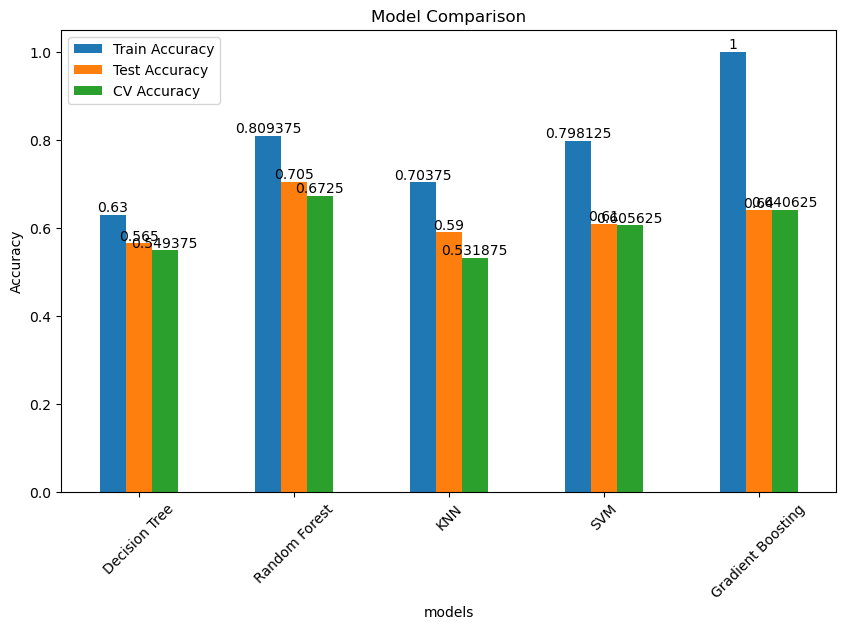

In [38]:
ax = results_df.set_index("models").plot(kind='bar', figsize=(10,6))

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

In [39]:
X.columns

Index(['N', 'P', 'K', 'Temperature', 'pH', 'Humidity', 'Rainfall',
       'Region_encoded'],
      dtype='object')

## Select Best Model

In [40]:
models = {
    "Decision Tree": accuracy_score(y_test, y_pred),
    "Random Forest": acc_rf,
    "KNN": acc_knn,
    "SVM": acc_svm,
    "Gradient Boosting": acc_gb
}

best_model = max(models, key=models.get)
print("\nBest Model:", best_model, "with accuracy:", models[best_model])


Best Model: Random Forest with accuracy: 0.705


### Feature importance

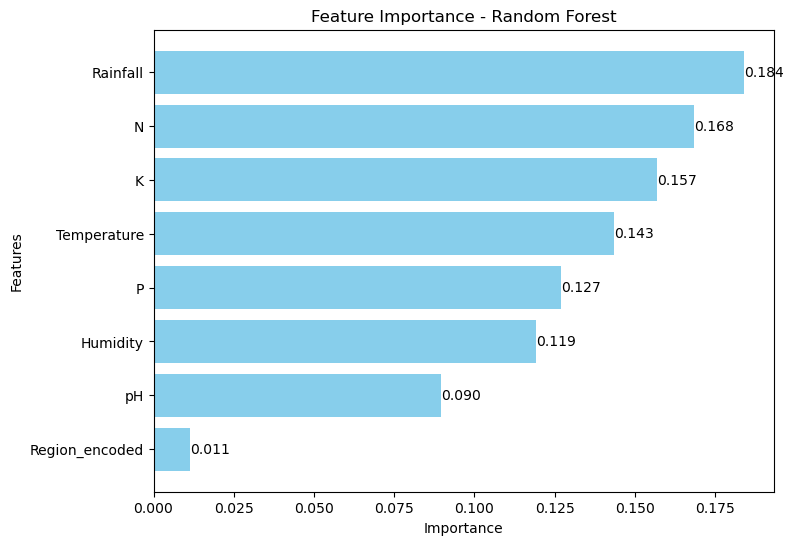

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Use the best trained model
best_model = rf   # Random Forest from your project

# Get feature importance values
importances = best_model.feature_importances_

# Get feature names from dataset
feature_names = X.columns

# Sort feature importance
indices = np.argsort(importances)

# Create figure
plt.figure(figsize=(8,6))

# Horizontal bar plot
bars = plt.barh(range(len(indices)), importances[indices], color='skyblue')

# Feature names
plt.yticks(range(len(indices)), feature_names[indices])

# Labels and title
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

# Add importance values on bars
for i, v in enumerate(importances[indices]):
    plt.text(
        v,
        i,
        f"{v:.3f}",
        va='center'
    )

# Show plot
plt.show()

In [42]:
#models_name = list(models.keys())
#accuracy_values = list(models.values())

#plt.bar(models_name, accuracy_values)
#plt.title("Model Accuracy Comparison")
#plt.xticks(rotation=45)
#plt.show()

## Step 8: Model Evaluation

### 1. Confusion Matrix

In [43]:
#cm = confusion_matrix(y_test, y_pred_rf)  # use My best model

#plt.figure(figsize=(9, 6))
#sb.heatmap(cm, annot=True, fmt='d')
#plt.title("Confusion Matrix")
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.show()

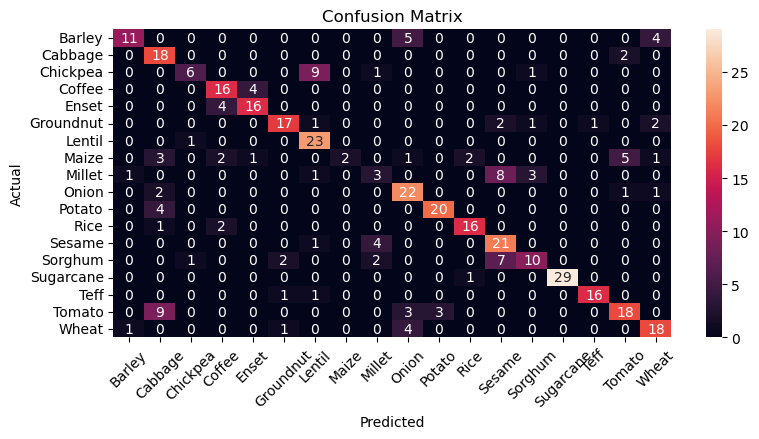

In [44]:
cm = confusion_matrix(y_test, y_pred_rf) # use My best model

plt.figure(figsize=(9, 4))

sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le_crop.classes_,   # Predicted labels
    yticklabels=le_crop.classes_    # Actual labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

### 2. Classification Report

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.55      0.67        20
           1       0.49      0.90      0.63        20
           2       0.75      0.35      0.48        17
           3       0.67      0.80      0.73        20
           4       0.76      0.80      0.78        20
           5       0.81      0.71      0.76        24
           6       0.64      0.96      0.77        24
           7       1.00      0.12      0.21        17
           8       0.30      0.19      0.23        16
           9       0.63      0.85      0.72        26
          10       0.87      0.83      0.85        24
          11       0.84      0.84      0.84        19
          12       0.55      0.81      0.66        26
          13       0.67      0.45      0.54        22
          14       1.00      0.97      0.98        30
          15       0.94      0.89      0.91        18
          16       0.69      0.55      0.61        33
          17       0.69    

In [46]:
#Check Overfitting
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5)
print("Train Accuracy:", rf.score(X_train, y_train))
print("Cross Validation Accuracy:", scores.mean())
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 0.809375
Cross Validation Accuracy: 0.6785
Test Accuracy: 0.705


## Step 9: Save the Model

In [47]:
import joblib

joblib.dump(rf, "Random Forest model.pkl")

['Random Forest model.pkl']

In [48]:
model = joblib.load("Random Forest model.pkl")

In [49]:
import joblib

# Save model + encoders + scaler
#joblib.dump(rf, "Random Forest model.pkl")
#joblib.dump(le_region, "region_encoder.pkl")
#joblib.dump(le_crop, "crop_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']